In [5]:
import yfinance as yf
import pandas as pd

tickers = [
    "AAPL",
    "TSLA",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS"
]

# Download data
df = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-01-01",
    group_by='ticker',
    auto_adjust=True
)
df.columns = [
    f"{col[0]}_{col[1]}"
    for col in df.columns
]
df.reset_index(inplace=True)
print(df.head())
df.to_csv("stocks.csv", index=False)

[*********************100%***********************]  11 of 11 completed


        Date  RELIANCE.NS_Open  RELIANCE.NS_High  RELIANCE.NS_Low  \
0 2018-01-01        407.585208        407.585208       400.870911   
1 2018-01-02        403.300424        406.193768       400.384994   
2 2018-01-03        408.601227        409.042975       403.322544   
3 2018-01-04        405.575300        407.187631       404.493061   
4 2018-01-05        407.187694        409.440517       406.503001   

   RELIANCE.NS_Close  RELIANCE.NS_Volume  TCS.NS_Open  TCS.NS_High  \
0         401.864807           9453202.0  1084.106227  1089.158356   
1         402.483215           9499419.0  1075.093499  1078.973575   
2         404.095581          13507800.0  1063.776418  1078.730722   
3         406.525024           9008932.0  1071.051250  1075.901293   
4         407.828186           7441284.0  1071.051439  1091.057872   

    TCS.NS_Low  TCS.NS_Close  ...  INFY.NS_Open  INFY.NS_High  INFY.NS_Low  \
0  1064.988948   1069.273193  ...    416.911518    419.643539   413.817947   
1  1059.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("stocks.csv", index_col=0, parse_dates=True)
close_prices = df[[col for col in df.columns if col.endswith("_Close")]]
close_prices.columns = [col.replace("_Close", "") for col in close_prices.columns]
close_prices.dropna(how="all", inplace=True)
def check_stationarity(series, ticker):
    print(f"\n{'='*55}")
    print(f"  Ticker: {ticker}")
    print(f"{'='*55}")
    adf_result = adfuller(series.dropna(), autolag="AIC")
    adf_pval = adf_result[1]
    adf_stat = "STATIONARY" if adf_pval < 0.05 else "NON-STATIONARY"

    print(f"\n[ADF Test]")
    print(f"  Test Statistic : {adf_result[0]:.4f}")
    print(f"  p-value        : {adf_pval:.4f}  →  {adf_stat}")

    # --- KPSS Test ---
    kpss_result = kpss(series.dropna(), regression="c", nlags="auto")
    kpss_pval = kpss_result[1]
    kpss_stat = "STATIONARY" if kpss_pval > 0.05 else "NON-STATIONARY "

    print(f"\n[KPSS Test]")
    print(f"  Test Statistic : {kpss_result[0]:.4f}")
    print(f"  p-value        : {kpss_pval:.4f}  →  {kpss_stat}")

    # --- Combined Verdict ---
    print(f"\n[Verdict]")
    if adf_pval < 0.05 and kpss_pval > 0.05:
        print("  → Stationary (both tests agree) ")
    elif adf_pval >= 0.05 and kpss_pval <= 0.05:
        print("Non-Stationary (both tests agree)— needs differencing")
    else:
        print(" → Inconclusive— check ACF/PACF plot")
results = {}
for ticker in close_prices.columns:
    series = close_prices[ticker].dropna()
    check_stationarity(series, ticker)

    adf_p = adfuller(series, autolag="AIC")[1]
    kpss_p = kpss(series, regression="c", nlags="auto")[1]

    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = "Stationary"
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        verdict = "Non-Stationary"
    else:
        verdict = "Inconclusive"

    results[ticker] = {"ADF p-value": round(adf_p, 4), "KPSS p-value": round(kpss_p, 4), "Verdict": verdict}
results_df = pd.DataFrame(results).T
results_df.index.name = "Ticker"
print("\n===== STATIONARITY SUMMARY =====\n")
print(results_df.to_string())


  Ticker: RELIANCE.NS

[ADF Test]
  Test Statistic : -1.0631
  p-value        : 0.7296  →  NON-STATIONARY

[KPSS Test]
  Test Statistic : 6.6452
  p-value        : 0.0100  →  NON-STATIONARY 

[Verdict]
Non-Stationary (both tests agree)— needs differencing

  Ticker: TCS.NS

[ADF Test]
  Test Statistic : -1.8907
  p-value        : 0.3365  →  NON-STATIONARY

[KPSS Test]
  Test Statistic : 5.8787
  p-value        : 0.0100  →  NON-STATIONARY 

[Verdict]
Non-Stationary (both tests agree)— needs differencing

  Ticker: NVDA

[ADF Test]
  Test Statistic : 1.4331
  p-value        : 0.9973  →  NON-STATIONARY

[KPSS Test]
  Test Statistic : 5.1653
  p-value        : 0.0100  →  NON-STATIONARY 

[Verdict]
Non-Stationary (both tests agree)— needs differencing

  Ticker: AMZN

[ADF Test]
  Test Statistic : -1.3259
  p-value        : 0.6172  →  NON-STATIONARY

[KPSS Test]
  Test Statistic : 4.3267
  p-value        : 0.0100  →  NON-STATIONARY 

[Verdict]
Non-Stationary (both tests agree)— needs diffe

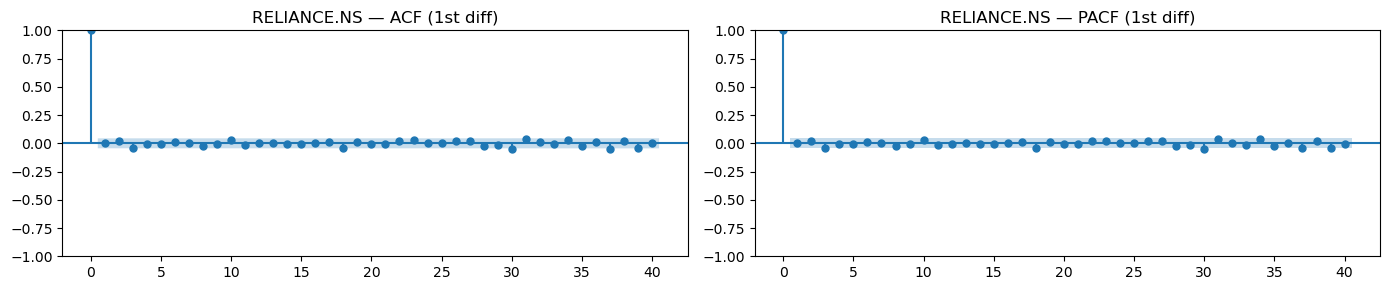

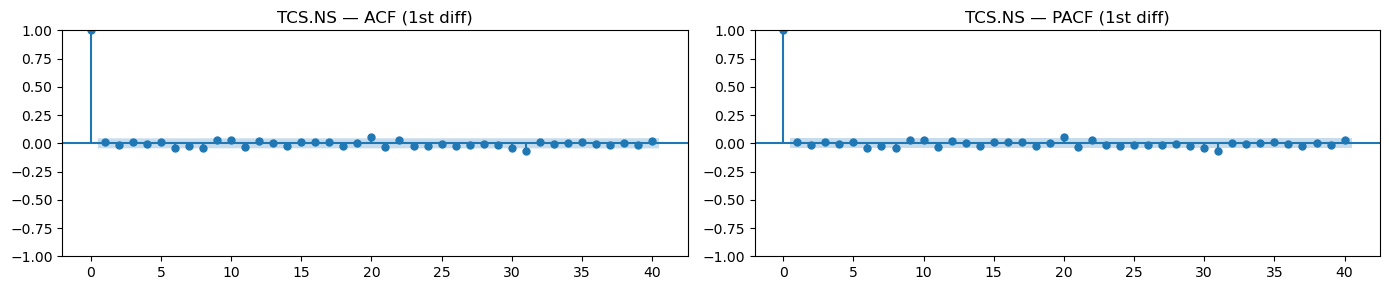

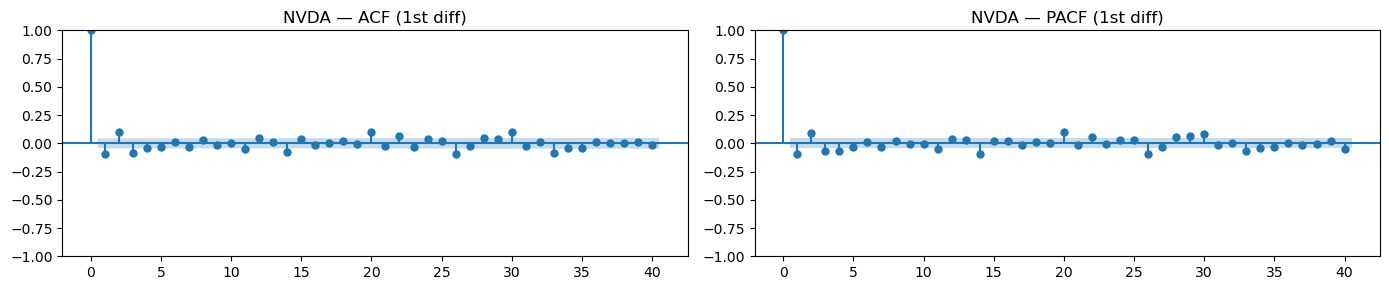

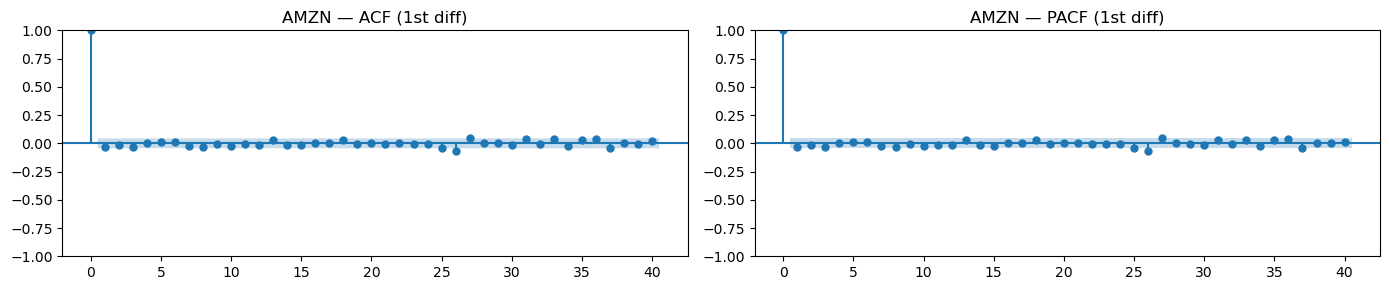

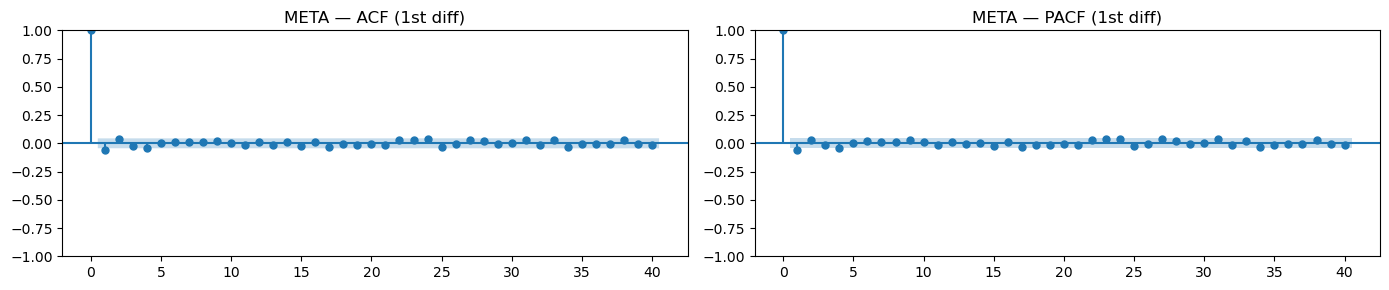

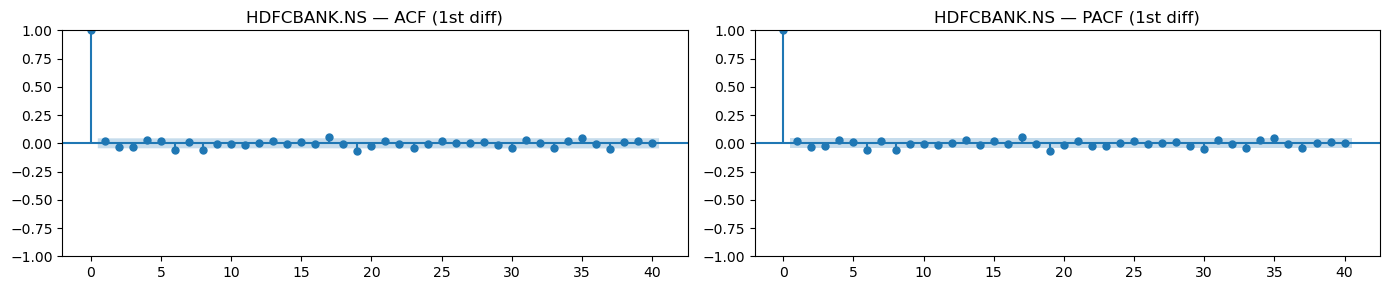

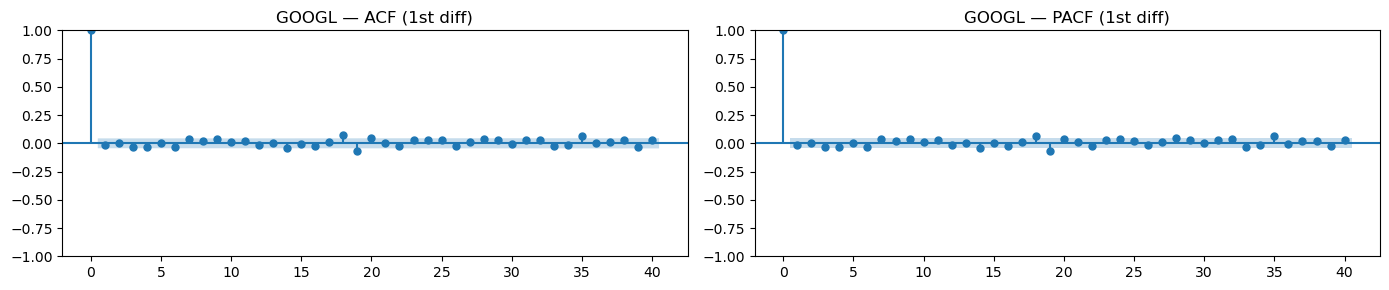

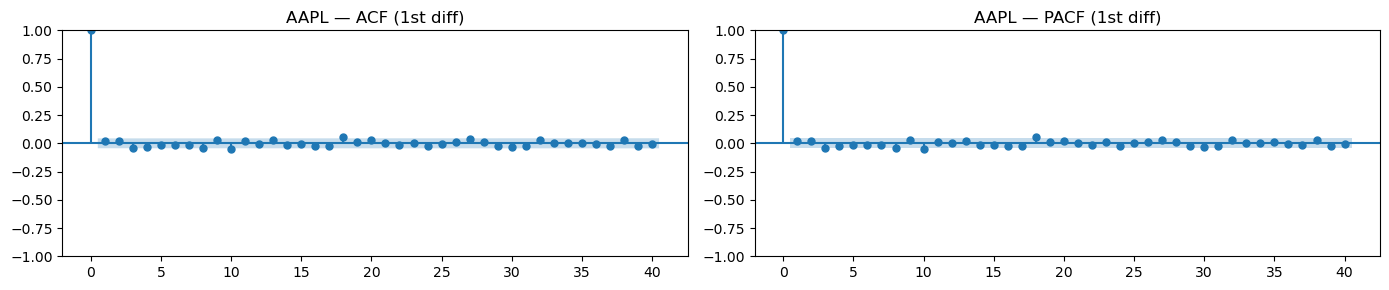

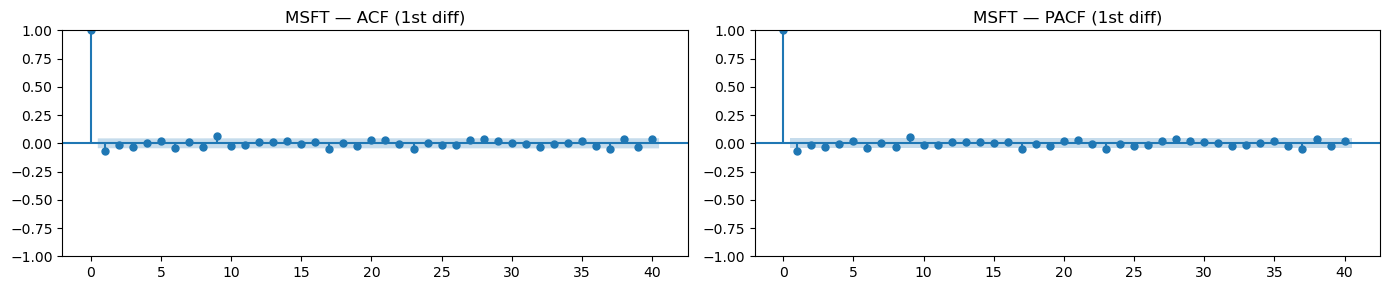

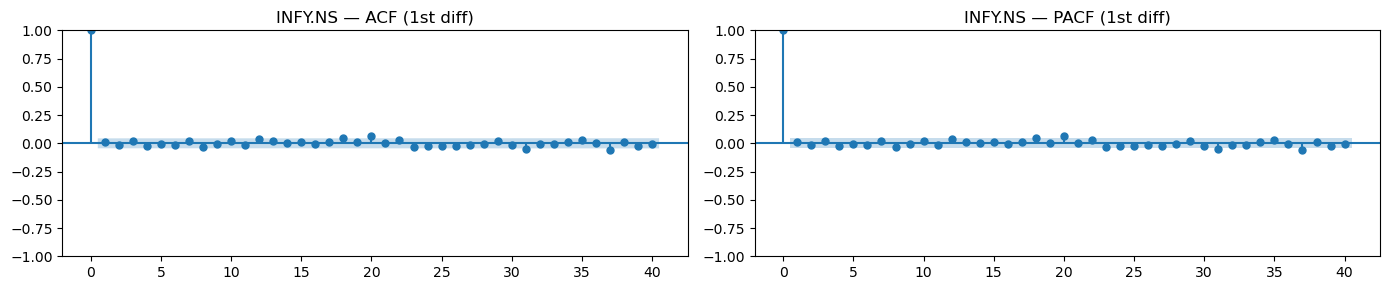

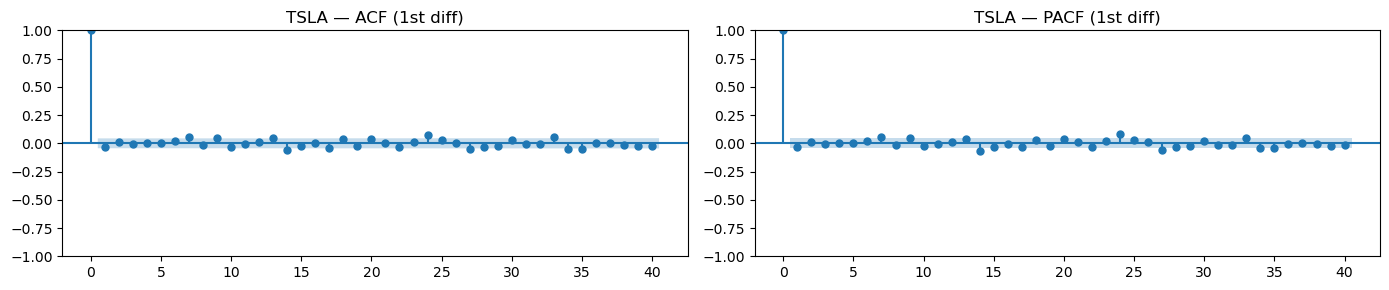

In [10]:
# ACF / PACF for non-stationary tickers
non_stationary = results_df[results_df["Verdict"] == "Non-Stationary"].index.tolist()
for ticker in non_stationary:
    series = close_prices[ticker].dropna()
    diff_series = series.diff().dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    plot_acf(diff_series, lags=40, ax=axes[0], title=f"{ticker} — ACF (1st diff)")
    plot_pacf(diff_series, lags=40, ax=axes[1], title=f"{ticker} — PACF (1st diff)")
    plt.tight_layout()
    plt.show()

In [13]:
# Stationarity check on 1st differenced series
diff_results = {}

for ticker in close_prices.columns:
    series = close_prices[ticker].dropna()
    diff_series = series.diff().dropna()

    adf_p = adfuller(diff_series, autolag="AIC")[1]
    kpss_p = kpss(diff_series, regression="c", nlags="auto")[1]

    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = "Stationary"
        d_value = 1
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        verdict = "Still Non-Stationary"
        d_value = 2 
    else:
        verdict = "Inconclusive"
        d_value = 1 

    diff_results[ticker] = {
        "ADF p-value"  : round(adf_p, 4),
        "KPSS p-value" : round(kpss_p, 4),
        "Verdict"      : verdict,
        "Use d="       : d_value
    }

diff_df = pd.DataFrame(diff_results).T
diff_df.index.name = "Ticker"
print("\n===== STATIONARITY AFTER 1ST DIFFERENCING =====\n")
print(diff_df.to_string())


===== STATIONARITY AFTER 1ST DIFFERENCING =====

            ADF p-value KPSS p-value       Verdict Use d=
Ticker                                                   
RELIANCE.NS         0.0          0.1    Stationary      1
TCS.NS              0.0          0.1    Stationary      1
NVDA                0.0       0.0231  Inconclusive      1
AMZN                0.0          0.1    Stationary      1
META                0.0          0.1    Stationary      1
HDFCBANK.NS         0.0          0.1    Stationary      1
GOOGL               0.0       0.0243  Inconclusive      1
AAPL                0.0          0.1    Stationary      1
MSFT                0.0          0.1    Stationary      1
INFY.NS             0.0          0.1    Stationary      1
TSLA                0.0          0.1    Stationary      1


Inconclusive tickers: ['NVDA', 'GOOGL']


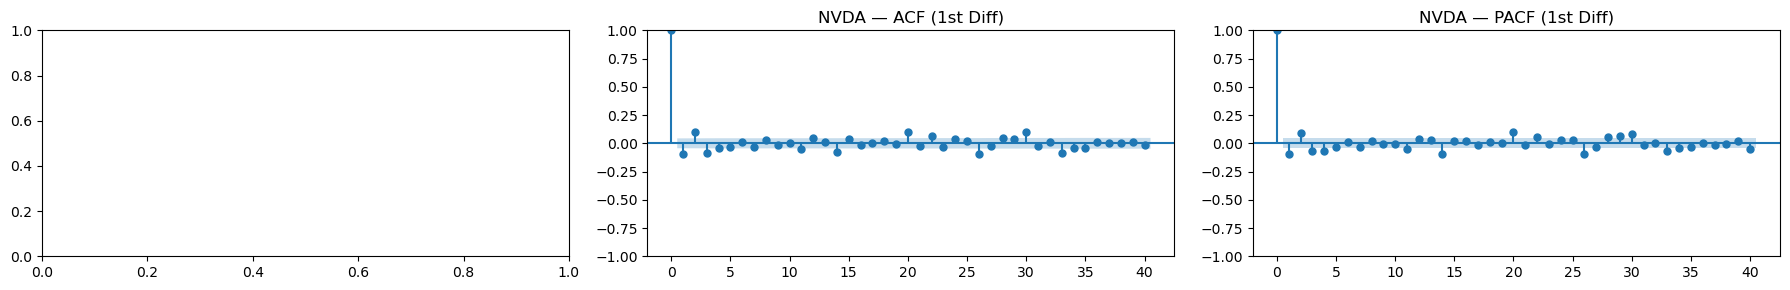


[NVDA] Manual check:
  Mean of diff series (should be ~0): 0.0903
  Std  of diff series (should be stable): 2.0234
  → Mean is near 0, rolling looks stable → treat as STATIONARY → d=1 


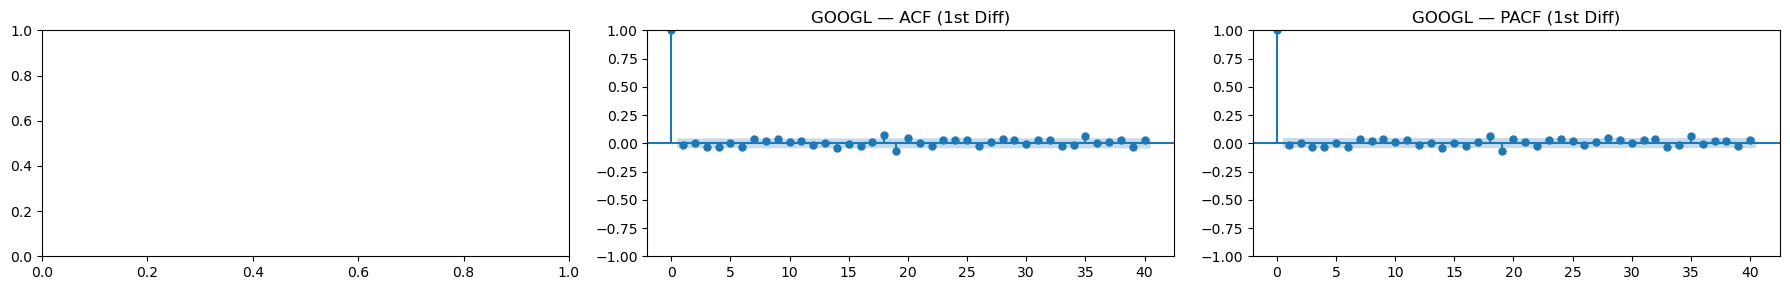


[GOOGL] Manual check:
  Mean of diff series (should be ~0): 0.1291
  Std  of diff series (should be stable): 2.4009
  → Mean is near 0, rolling looks stable → treat as STATIONARY → d=1 


In [17]:
# Deeper diagnosis for inconclusive tickers
inconclusive = diff_df[diff_df["Verdict"].str.contains("Inconclusive")].index.tolist()
print(f"Inconclusive tickers: {inconclusive}")

for ticker in inconclusive:
    series = close_prices[ticker].dropna()
    diff_series = series.diff().dropna()

    fig, axes = plt.subplots(1, 3, figsize=(18, 3))

   
    # 2. ACF
    plot_acf(diff_series, lags=40, ax=axes[1], title=f"{ticker} — ACF (1st Diff)")

    # 3. PACF
    plot_pacf(diff_series, lags=40, ax=axes[2], title=f"{ticker} — PACF (1st Diff)")

    plt.tight_layout()
    plt.show()

    print(f"\n[{ticker}] Manual check:")
    print(f"  Mean of diff series (should be ~0): {diff_series.mean():.4f}")
    print(f"  Std  of diff series (should be stable): {diff_series.std():.4f}")
    if abs(diff_series.mean()) < 1.0:
        print(f"  → Mean is near 0, rolling looks stable → treat as STATIONARY → d=1 ")
    else:
        print(f"  → Mean is drifting → treat as NON-STATIONARY → consider d=2 ")

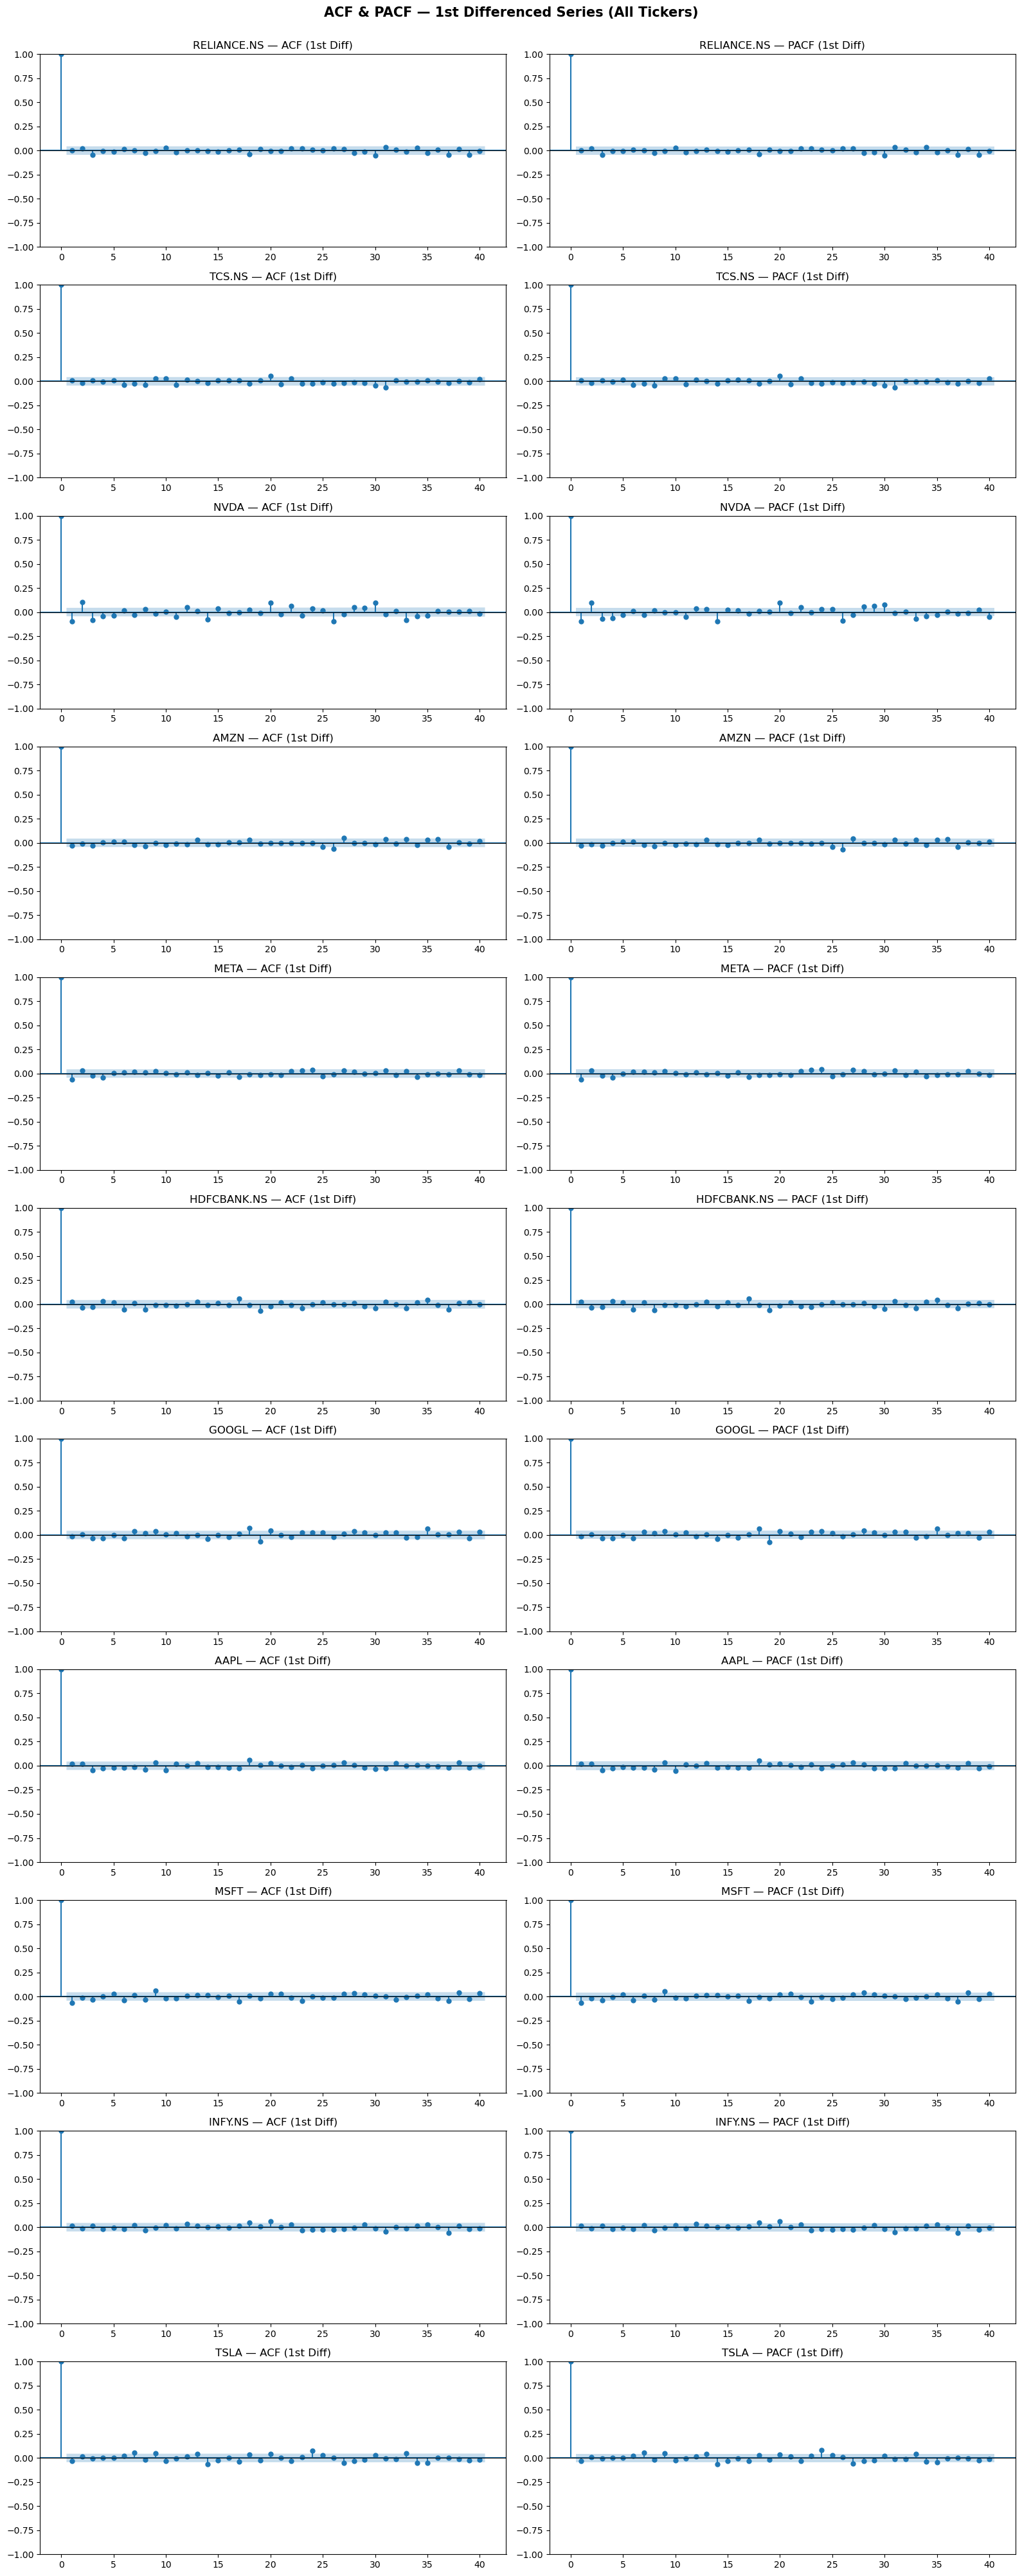

In [18]:
#ACF & PACF plots for all tickers on 1st differenced series
fig, axes = plt.subplots(nrows=11, ncols=2, figsize=(16, 40))

for i, ticker in enumerate(close_prices.columns):
    diff_series = close_prices[ticker].dropna().diff().dropna()

    plot_acf(diff_series,  lags=40, ax=axes[i][0], title=f"{ticker} — ACF (1st Diff)",  alpha=0.05)
    plot_pacf(diff_series, lags=40, ax=axes[i][1], title=f"{ticker} — PACF (1st Diff)", alpha=0.05)

    axes[i][0].axhline(0, color="black", linewidth=0.8)
    axes[i][1].axhline(0, color="black", linewidth=0.8)

plt.suptitle("ACF & PACF — 1st Differenced Series (All Tickers)", fontsize=15, fontweight="bold", y=1.001)
plt.tight_layout()
plt.show()

In [19]:
# ARIMA
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import TimeSeriesSplit
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
sample_series = close_prices["AAPL"].dropna()

print(f"Total samples : {len(sample_series)}")
print(f"Splits        : {N_SPLITS}\n")
print(f"{'Split':<8} {'Train Start':<14} {'Train End':<14} {'Test Start':<14} {'Test End':<14} {'Train Size':<12} {'Test Size'}")
print("-" * 85)

for fold, (train_idx, test_idx) in enumerate(tscv.split(sample_series)):
    print(f"Fold {fold+1:<3} "
          f"{str(sample_series.index[train_idx[0]].date()):<14} "
          f"{str(sample_series.index[train_idx[-1]].date()):<14} "
          f"{str(sample_series.index[test_idx[0]].date()):<14} "
          f"{str(sample_series.index[test_idx[-1]].date()):<14} "
          f"{len(train_idx):<12} "
          f"{len(test_idx)}")

Total samples : 2011
Splits        : 5

Split    Train Start    Train End      Test Start     Test End       Train Size   Test Size
-------------------------------------------------------------------------------------
Fold 1   2018-01-02     2019-05-03     2019-05-06     2020-08-31     336          335
Fold 2   2018-01-02     2020-08-31     2020-09-01     2021-12-29     671          335
Fold 3   2018-01-02     2021-12-29     2021-12-30     2023-05-01     1006         335
Fold 4   2018-01-02     2023-05-01     2023-05-02     2024-08-29     1341         335
Fold 5   2018-01-02     2024-08-29     2024-08-30     2025-12-31     1676         335


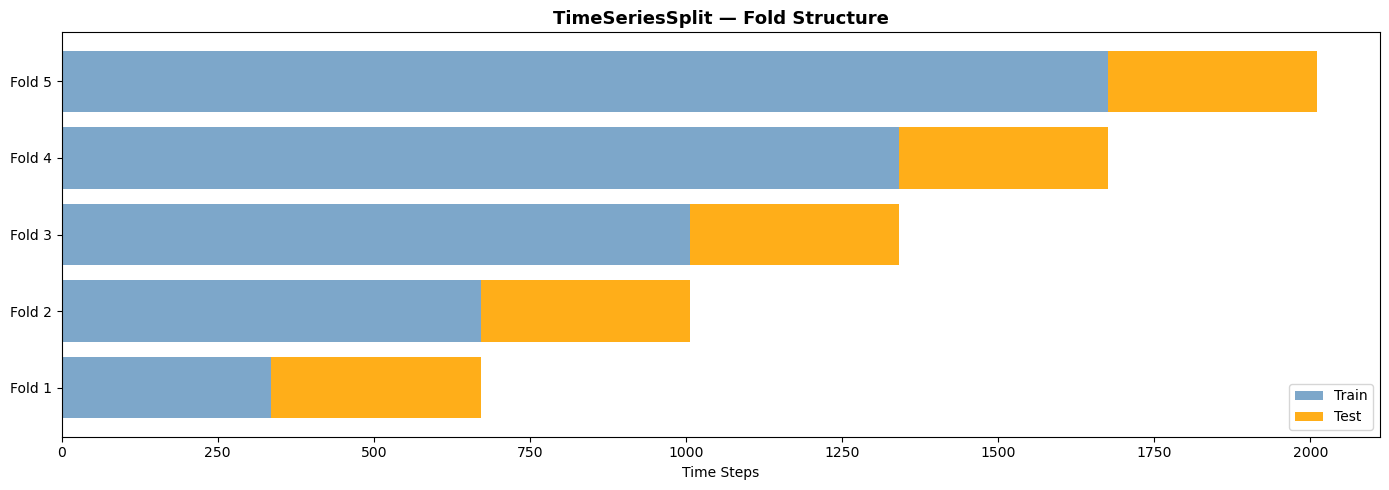

In [20]:
 # Visualize TimeSeriesSplit folds
fig, ax = plt.subplots(figsize=(14, 5))

for fold, (train_idx, test_idx) in enumerate(tscv.split(sample_series)):
    ax.barh(y=fold, width=len(train_idx), left=train_idx[0],
            color="steelblue", alpha=0.7, label="Train" if fold == 0 else "")
    ax.barh(y=fold, width=len(test_idx), left=test_idx[0],
            color="orange", alpha=0.9, label="Test" if fold == 0 else "")

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax.set_xlabel("Time Steps")
ax.set_title("TimeSeriesSplit — Fold Structure", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
#  Run ARIMA(1,1,1) across all folds for all tickers
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

arima_results = {}

for ticker in close_prices.columns:
    series = close_prices[ticker].dropna()
    fold_metrics = []

    print(f"\n{'='*50}")
    print(f"  {ticker}")
    print(f"{'='*50}")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(series)):
        train = series.iloc[train_idx]
        test  = series.iloc[test_idx]

        # Walk-forward forecast on this fold's test set
        history = list(train)
        preds   = []

        for t in range(len(test)):
            model  = ARIMA(history, order=(1, 1, 1))
            fitted = model.fit()
            yhat   = fitted.forecast(steps=1)[0]
            preds.append(yhat)
            history.append(test.iloc[t])

        preds   = np.array(preds)
        actuals = test.values

        mae  = mean_absolute_error(actuals, preds)
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mape = np.mean(np.abs((actuals - preds) / actuals)) * 100

        fold_metrics.append({
            "fold"       : fold + 1,
            "train_size" : len(train),
            "test_size"  : len(test),
            "preds"      : preds,
            "actuals"    : actuals,
            "test_index" : test.index,
            "MAE"        : round(mae, 4),
            "RMSE"       : round(rmse, 4),
            "MAPE"       : round(mape, 4)
        })

        print(f"  Fold {fold+1} → MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}%")

    # Average metrics across all folds
    avg_mae  = round(np.mean([f["MAE"]  for f in fold_metrics]), 4)
    avg_rmse = round(np.mean([f["RMSE"] for f in fold_metrics]), 4)
    avg_mape = round(np.mean([f["MAPE"] for f in fold_metrics]), 4)

    print(f"\n  Avg → MAE: {avg_mae} | RMSE: {avg_rmse} | MAPE: {avg_mape}%")

    arima_results[ticker] = {
        "folds"    : fold_metrics,
        "avg_MAE"  : avg_mae,
        "avg_RMSE" : avg_rmse,
        "avg_MAPE" : avg_mape
    }


  RELIANCE.NS
  Fold 1 → MAE: 10.8398 | RMSE: 15.7516 | MAPE: 1.72%
  Fold 2 → MAE: 12.4830 | RMSE: 16.9294 | MAPE: 1.27%
  Fold 3 → MAE: 13.3546 | RMSE: 17.9452 | MAPE: 1.18%
  Fold 4 → MAE: 11.9621 | RMSE: 17.5305 | MAPE: 0.89%
  Fold 5 → MAE: 12.5822 | RMSE: 16.8068 | MAPE: 0.93%

  Avg → MAE: 12.2443 | RMSE: 16.9927 | MAPE: 1.1975%

  TCS.NS
  Fold 1 → MAE: 23.9311 | RMSE: 33.1652 | MAPE: 1.38%
  Fold 2 → MAE: 28.4692 | RMSE: 39.1852 | MAPE: 1.04%
  Fold 3 → MAE: 31.3963 | RMSE: 41.7492 | MAPE: 1.05%
  Fold 4 → MAE: 31.4618 | RMSE: 44.0857 | MAPE: 0.90%
  Fold 5 → MAE: 30.3514 | RMSE: 43.5227 | MAPE: 0.88%

  Avg → MAE: 29.122 | RMSE: 40.3416 | MAPE: 1.0527%

  NVDA
  Fold 1 → MAE: 0.1409 | RMSE: 0.2072 | MAPE: 2.23%
  Fold 2 → MAE: 0.3925 | RMSE: 0.5711 | MAPE: 2.15%
  Fold 3 → MAE: 0.5866 | RMSE: 0.7482 | MAPE: 3.02%
  Fold 4 → MAE: 1.7212 | RMSE: 2.6576 | MAPE: 2.31%
  Fold 5 → MAE: 3.0122 | RMSE: 4.0601 | MAPE: 2.14%

  Avg → MAE: 1.1707 | RMSE: 1.6488 | MAPE: 2.3705%

  AMZN


In [22]:
# Averaged metrics summary table
summary = {
    ticker: {
        "Avg MAE"  : arima_results[ticker]["avg_MAE"],
        "Avg RMSE" : arima_results[ticker]["avg_RMSE"],
        "Avg MAPE%": arima_results[ticker]["avg_MAPE"]
    }
    for ticker in close_prices.columns
}

summary_df = pd.DataFrame(summary).T
summary_df.index.name = "Ticker"
print("\n===== ARIMA(1,1,1) — CROSS-VALIDATED PERFORMANCE (5 Folds) =====\n")
print(summary_df.to_string())


===== ARIMA(1,1,1) — CROSS-VALIDATED PERFORMANCE (5 Folds) =====

             Avg MAE  Avg RMSE  Avg MAPE%
Ticker                                   
RELIANCE.NS  12.2443   16.9927     1.1975
TCS.NS       29.1220   40.3416     1.0527
NVDA          1.1707    1.6488     2.3705
AMZN          2.2980    3.1690     1.5535
META          5.5627    8.2971     1.7574
HDFCBANK.NS   7.3617   10.3447     1.0761
GOOGL         1.7642    2.4360     1.4200
AAPL          1.9660    2.7521     1.3614
MSFT          3.4934    4.7502     1.2580
INFY.NS      14.7309   20.4244     1.2020
TSLA          6.1397    8.4933     2.9262


In [25]:
from arch import arch_model
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

In [36]:
# Cell 13b FIXED — Feature engineering on log returns (stationary)
def create_lag_features(series, lags=10):
    df = pd.DataFrame(series)
    df.columns = ["price"]

    # Predict log returns instead of raw price
    df["log_return"] = np.log(df["price"] / df["price"].shift(1))

    for lag in range(1, lags + 1):
        df[f"lag_{lag}"] = df["log_return"].shift(lag)

    # Rolling features on returns
    df["roll_mean_5"]  = df["log_return"].rolling(5).mean()
    df["roll_mean_10"] = df["log_return"].rolling(10).mean()
    df["roll_std_5"]   = df["log_return"].rolling(5).std()
    df["roll_std_10"]  = df["log_return"].rolling(10).std()

    # Momentum
    df["momentum_5"]  = df["log_return"].rolling(5).sum()
    df["momentum_10"] = df["log_return"].rolling(10).sum()

    df.dropna(inplace=True)
    return df

In [37]:
#  Train XGBoost with TimeSeriesSplit for TSLA & NVDA
xgb_results = {}

for ticker in volatile_tickers:
    print(f"\n{'='*55}")
    print(f"  XGBoost (log returns) — {ticker}")
    print(f"{'='*55}")

    series   = close_prices[ticker].dropna()
    feat_df  = create_lag_features(series, lags=10)

    # Target = log return, not price
    X = feat_df.drop(columns=["price", "log_return"])
    y = feat_df["log_return"]
    prices = feat_df["price"]   # keep actual prices for metric calc

    fold_metrics = []
    fold_preds   = []
    tscv         = TimeSeriesSplit(n_splits=5)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test   = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test   = y.iloc[train_idx], y.iloc[test_idx]
        price_test        = prices.iloc[test_idx]
        price_prev        = prices.iloc[test_idx[0] - 1]  # price before test window

        scaler   = StandardScaler()
        X_train  = scaler.fit_transform(X_train)
        X_test   = scaler.transform(X_test)

        model = XGBRegressor(
            n_estimators     = 100,     # reduced
            max_depth        = 3,       # shallower
            learning_rate    = 0.05,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            random_state     = 42,
            verbosity        = 0
        )
        model.fit(X_train, y_train)

        # Predict returns
        pred_returns = model.predict(X_test)

        # Reconstruct prices from predicted returns
        pred_prices = [price_prev]
        for r in pred_returns:
            pred_prices.append(pred_prices[-1] * np.exp(r))
        pred_prices = np.array(pred_prices[1:])

        actual_prices = price_test.values

        mae  = mean_absolute_error(actual_prices, pred_prices)
        rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
        mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100

        fold_metrics.append({
            "fold" : fold + 1,
            "MAE"  : round(mae, 4),
            "RMSE" : round(rmse, 4),
            "MAPE" : round(mape, 4)
        })
        fold_preds.append({
            "test_index" : price_test.index,
            "actuals"    : actual_prices,
            "preds"      : pred_prices
        })

        print(f"  Fold {fold+1} → MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}%")

    avg_mae  = round(np.mean([f["MAE"]  for f in fold_metrics]), 4)
    avg_rmse = round(np.mean([f["RMSE"] for f in fold_metrics]), 4)
    avg_mape = round(np.mean([f["MAPE"] for f in fold_metrics]), 4)

    print(f"\n  Avg → MAE: {avg_mae} | RMSE: {avg_rmse} | MAPE: {avg_mape}%")

    # Refit on full data
    scaler_full = StandardScaler()
    X_full      = scaler_full.fit_transform(X)
    final_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, verbosity=0)
    final_model.fit(X_full, y)

    xgb_results[ticker] = {
        "model"       : final_model,
        "scaler"      : scaler_full,
        "feat_df"     : feat_df,
        "fold_preds"  : fold_preds,
        "fold_metrics": fold_metrics,
        "avg_MAE"     : avg_mae,
        "avg_RMSE"    : avg_rmse,
        "avg_MAPE"    : avg_mape
    }


  XGBoost (log returns) — TSLA
  Fold 1 → MAE: 22.8293 | RMSE: 33.6526 | MAPE: 40.42%
  Fold 2 → MAE: 25.0678 | RMSE: 29.7936 | MAPE: 10.71%
  Fold 3 → MAE: 13.0889 | RMSE: 16.0875 | MAPE: 5.80%
  Fold 4 → MAE: 10.9189 | RMSE: 14.4455 | MAPE: 5.03%
  Fold 5 → MAE: 41.9782 | RMSE: 52.3307 | MAPE: 11.70%

  Avg → MAE: 22.7766 | RMSE: 29.262 | MAPE: 14.7323%

  XGBoost (log returns) — NVDA
  Fold 1 → MAE: 0.5249 | RMSE: 0.7604 | MAPE: 6.42%
  Fold 2 → MAE: 0.6565 | RMSE: 0.8904 | MAPE: 3.43%
  Fold 3 → MAE: 6.1263 | RMSE: 6.7681 | MAPE: 32.25%
  Fold 4 → MAE: 6.6429 | RMSE: 8.2324 | MAPE: 8.96%
  Fold 5 → MAE: 13.2257 | RMSE: 14.7156 | MAPE: 9.23%

  Avg → MAE: 5.4353 | RMSE: 6.2734 | MAPE: 12.0581%


In [38]:
# Cell 13d FIXED — 7-day forecast using predicted returns
xgb_forecast_dict = {}

for ticker in volatile_tickers:
    series      = close_prices[ticker].dropna()
    feat_df     = xgb_results[ticker]["feat_df"]
    model       = xgb_results[ticker]["model"]
    scaler      = xgb_results[ticker]["scaler"]

    last_price  = series.iloc[-1]
    history     = list(np.log(series / series.shift(1)).dropna().values)  # log return history
    price_hist  = last_price
    future_preds= []

    for _ in range(7):
        # Build feature row from recent return history
        lags        = history[-10:][::-1]                          # lag_1 to lag_10
        roll_mean5  = np.mean(history[-5:])
        roll_mean10 = np.mean(history[-10:])
        roll_std5   = np.std(history[-5:])
        roll_std10  = np.std(history[-10:])
        mom5        = np.sum(history[-5:])
        mom10       = np.sum(history[-10:])

        row         = np.array(lags + [roll_mean5, roll_mean10, roll_std5, roll_std10, mom5, mom10])
        row_scaled  = scaler.transform(row.reshape(1, -1))

        pred_return = model.predict(row_scaled)[0]
        price_hist  = price_hist * np.exp(pred_return)

        future_preds.append(price_hist)
        history.append(pred_return)

    future_dates = pd.date_range(start=series.index[-1], periods=8, freq="B")[1:]
    xgb_forecast_dict[ticker] = pd.Series(future_preds, index=future_dates)

print("XGBoost 7-day forecasts (log return based) generated ✅")

XGBoost 7-day forecasts (log return based) generated ✅


In [39]:
# Fit GARCH(1,1) on TSLA & NVDA returns
garch_results = {}

for ticker in volatile_tickers:
    print(f"\n{'='*55}")
    print(f"  GARCH(1,1) — {ticker}")
    print(f"{'='*55}")

    series  = close_prices[ticker].dropna()
    returns = series.pct_change().dropna() * 100   # percentage returns

    # Fit GARCH(1,1)
    model  = arch_model(returns, vol="Garch", p=1, q=1, dist="normal")
    fitted = model.fit(disp="off")

    print(fitted.summary())

    # Conditional volatility (fitted)
    cond_vol = fitted.conditional_volatility

    # 7-day volatility forecast
    forecast    = fitted.forecast(horizon=7, reindex=False)
    vol_forecast= np.sqrt(forecast.variance.values[-1])  # annualised std

    future_dates = pd.date_range(start=series.index[-1], periods=8, freq="B")[1:]

    garch_results[ticker] = {
        "fitted"       : fitted,
        "returns"      : returns,
        "cond_vol"     : cond_vol,
        "vol_forecast" : pd.Series(vol_forecast, index=future_dates),
        "series"       : series
    }

    print(f"\n  7-day Volatility Forecast (%):")
    for date, vol in zip(future_dates, vol_forecast):
        print(f"    {date.date()} → ±{vol:.2f}%")


  GARCH(1,1) — TSLA
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   TSLA   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5566.05
Distribution:                  Normal   AIC:                           11140.1
Method:            Maximum Likelihood   BIC:                           11162.5
                                        No. Observations:                 2010
Date:                Fri, May 29 2026   Df Residuals:                     2009
Time:                        02:01:15   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.2314  8.715e-02      2.655

In [40]:
# ARIMA mean forecast + GARCH confidence bands (hybrid)
from statsmodels.tsa.arima.model import ARIMA

arima_garch_dict = {}

for ticker in volatile_tickers:
    print(f"\nFitting ARIMA(1,1,1) for {ticker} ...")
    series = close_prices[ticker].dropna()

    arima_model  = ARIMA(series, order=(1, 1, 1))
    arima_fitted = arima_model.fit()
    arima_fc     = arima_fitted.forecast(steps=7)

    future_dates = pd.date_range(start=series.index[-1], periods=8, freq="B")[1:]
    vol_forecast = garch_results[ticker]["vol_forecast"].values
    last_price   = series.iloc[-1]

    # Confidence bands: ARIMA forecast ± GARCH volatility scaled to price
    upper_band = arima_fc.values + (vol_forecast / 100) * last_price
    lower_band = arima_fc.values - (vol_forecast / 100) * last_price

    arima_garch_dict[ticker] = {
        "dates"      : future_dates,
        "arima_fc"   : pd.Series(arima_fc.values, index=future_dates),
        "upper"      : pd.Series(upper_band,       index=future_dates),
        "lower"      : pd.Series(lower_band,       index=future_dates),
    }

print("ARIMA-GARCH hybrid forecasts generated ✅")


Fitting ARIMA(1,1,1) for TSLA ...

Fitting ARIMA(1,1,1) for NVDA ...
ARIMA-GARCH hybrid forecasts generated ✅


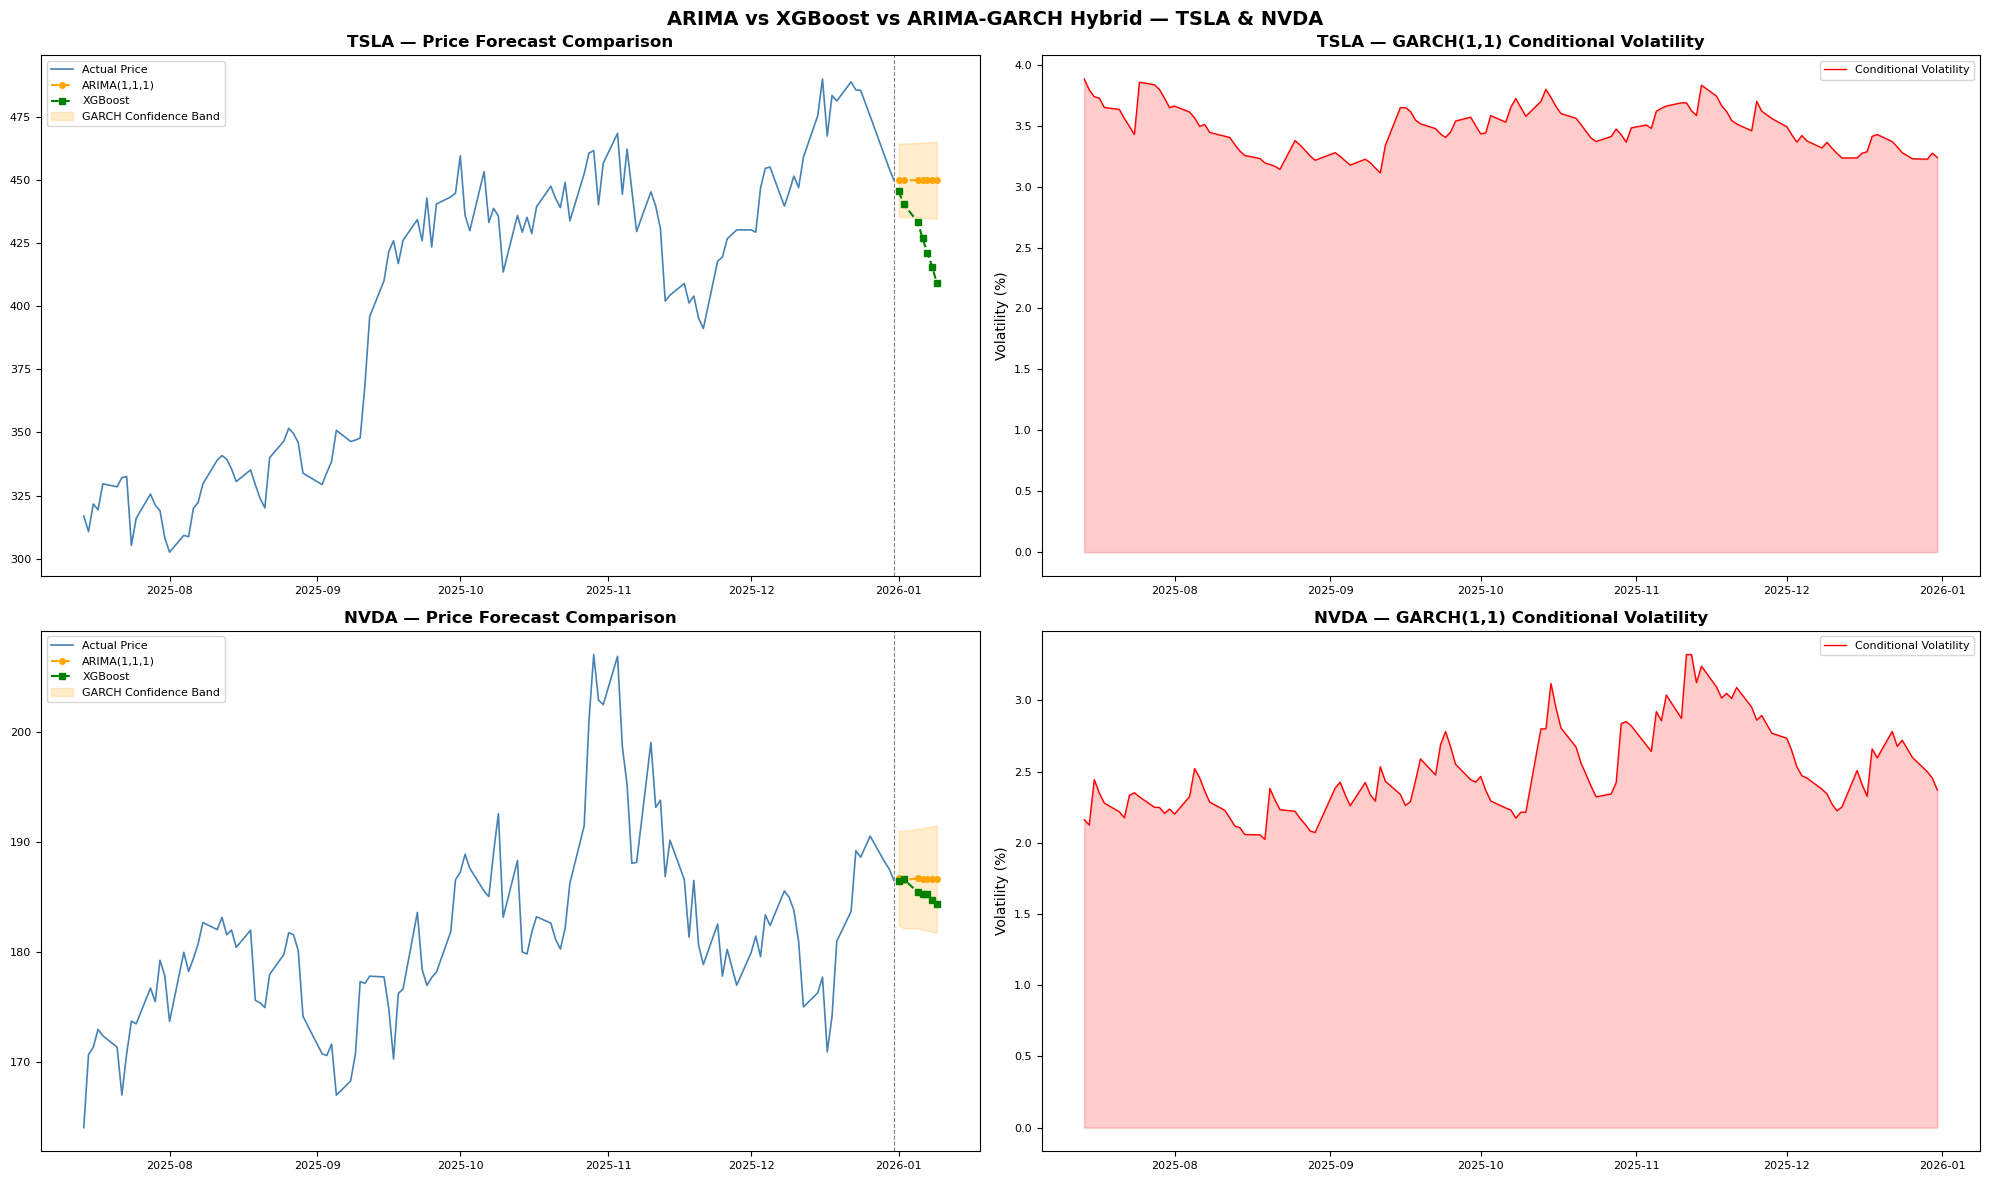

In [41]:
# Cell 13g — Full comparison plot (ARIMA vs XGBoost vs ARIMA-GARCH hybrid)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))

for i, ticker in enumerate(volatile_tickers):
    series       = close_prices[ticker].dropna()
    plot_window  = series.iloc[-120:]   # last 120 days for clarity

    xgb_fc       = xgb_forecast_dict[ticker]
    arima_fc     = arima_garch_dict[ticker]["arima_fc"]
    upper        = arima_garch_dict[ticker]["upper"]
    lower        = arima_garch_dict[ticker]["lower"]
    future_dates = arima_garch_dict[ticker]["dates"]
    cond_vol     = garch_results[ticker]["cond_vol"]

    # --- Left plot: Price forecast comparison ---
    ax1 = axes[i][0]
    ax1.plot(plot_window.index, plot_window.values,
             label="Actual Price", color="steelblue", linewidth=1.2)
    ax1.plot(future_dates, arima_fc.values,
             label="ARIMA(1,1,1)", color="orange", linewidth=1.5,
             linestyle="--", marker="o", markersize=4)
    ax1.plot(future_dates, xgb_fc.values,
             label="XGBoost", color="green", linewidth=1.5,
             linestyle="--", marker="s", markersize=4)
    ax1.fill_between(future_dates, lower.values, upper.values,
                     alpha=0.2, color="orange", label="GARCH Confidence Band")
    ax1.axvline(x=series.index[-1], color="gray", linestyle="--", linewidth=0.8)
    ax1.set_title(f"{ticker} — Price Forecast Comparison", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=8)
    ax1.tick_params(labelsize=8)

    # --- Right plot: GARCH conditional volatility ---
    ax2 = axes[i][1]
    ax2.plot(cond_vol.index[-120:], cond_vol.values[-120:],
             color="red", linewidth=1.0, label="Conditional Volatility")
    ax2.fill_between(cond_vol.index[-120:], 0, cond_vol.values[-120:],
                     alpha=0.2, color="red")
    ax2.set_title(f"{ticker} — GARCH(1,1) Conditional Volatility", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Volatility (%)")
    ax2.legend(fontsize=8)
    ax2.tick_params(labelsize=8)

plt.suptitle("ARIMA vs XGBoost vs ARIMA-GARCH Hybrid — TSLA & NVDA",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [42]:
# Cell 13h — Model comparison summary table
print("\n===== MODEL COMPARISON — TSLA & NVDA =====\n")

comparison = {}
for ticker in volatile_tickers:
    comparison[f"{ticker} — ARIMA"] = {
        "Avg MAE"  : arima_results[ticker]["avg_MAE"],
        "Avg RMSE" : arima_results[ticker]["avg_RMSE"],
        "Avg MAPE%": arima_results[ticker]["avg_MAPE"]
    }
    comparison[f"{ticker} — XGBoost"] = {
        "Avg MAE"  : xgb_results[ticker]["avg_MAE"],
        "Avg RMSE" : xgb_results[ticker]["avg_RMSE"],
        "Avg MAPE%": xgb_results[ticker]["avg_MAPE"]
    }

comp_df = pd.DataFrame(comparison).T
print(comp_df.to_string())
print("\n* GARCH predicts volatility, not price — compare via confidence band width")


===== MODEL COMPARISON — TSLA & NVDA =====

                Avg MAE  Avg RMSE  Avg MAPE%
TSLA — ARIMA     6.1397    8.4933     2.9262
TSLA — XGBoost  22.7766   29.2620    14.7323
NVDA — ARIMA     1.1707    1.6488     2.3705
NVDA — XGBoost   5.4353    6.2734    12.0581

* GARCH predicts volatility, not price — compare via confidence band width


In [44]:
#  GARCH Residual Diagnostics
from scipy import stats
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

for ticker in volatile_tickers:
    fitted    = garch_results[ticker]["fitted"]
    resid     = fitted.resid
    std_resid = fitted.resid / fitted.conditional_volatility  # standardised residuals

    print(f"\n{'='*55}")
    print(f"  GARCH Diagnostics — {ticker}")
    print(f"{'='*55}")

    # --- 1. Ljung-Box Test on standardised residuals ---
    # Tests if residuals are white noise (no autocorrelation left)
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_test = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
    print(f"\n[Ljung-Box Test — Standardised Residuals]")
    print(lb_test)
    print("  → p > 0.05 means no autocorrelation left ✅")

    # --- 2. ARCH-LM Test on standardised residuals ---
    # Tests if volatility clustering is fully captured
    arch_test = het_arch(std_resid, nlags=10)
    print(f"\n[ARCH-LM Test]")
    print(f"  Test Statistic : {arch_test[0]:.4f}")
    print(f"  p-value        : {arch_test[1]:.4f}")
    if arch_test[1] > 0.05:
        print("  → No remaining ARCH effects ✅ (GARCH captured volatility well)")
    else:
        print("  → ARCH effects still present ❌ (consider GARCH(1,2) or GJR-GARCH)")

    # --- 3. Normality Test on standardised residuals ---
    stat, p = stats.jarque_bera(std_resid)
    print(f"\n[Jarque-Bera Normality Test]")
    print(f"  Test Statistic : {stat:.4f}")
    print(f"  p-value        : {p:.4f}")
    if p > 0.05:
        print("  → Residuals are normal ✅")
    else:
        print("  → Residuals are non-normal ⚠️ (fat tails — expected for stocks)")


  GARCH Diagnostics — TSLA

[Ljung-Box Test — Standardised Residuals]
      lb_stat  lb_pvalue
10  10.726368   0.379230
20  24.935982   0.203891
  → p > 0.05 means no autocorrelation left ✅

[ARCH-LM Test]
  Test Statistic : 10.5011
  p-value        : 0.3977
  → No remaining ARCH effects ✅ (GARCH captured volatility well)

[Jarque-Bera Normality Test]
  Test Statistic : 1069.8859
  p-value        : 0.0000
  → Residuals are non-normal ⚠️ (fat tails — expected for stocks)

  GARCH Diagnostics — NVDA

[Ljung-Box Test — Standardised Residuals]
      lb_stat  lb_pvalue
10   8.976676   0.534319
20  16.806495   0.665501
  → p > 0.05 means no autocorrelation left ✅

[ARCH-LM Test]
  Test Statistic : 2.9497
  p-value        : 0.9826
  → No remaining ARCH effects ✅ (GARCH captured volatility well)

[Jarque-Bera Normality Test]
  Test Statistic : 3064.3055
  p-value        : 0.0000
  → Residuals are non-normal ⚠️ (fat tails — expected for stocks)


In [45]:
# Cell — Imports for saving
import pickle
import joblib
import os
from statsmodels.tsa.arima.model import ARIMAResults

# Create directory structure
os.makedirs("models/arima",  exist_ok=True)
os.makedirs("models/garch",  exist_ok=True)
os.makedirs("models/data",   exist_ok=True)

print("📁 Directory structure created ✅")

📁 Directory structure created ✅


In [46]:
# Cell — Save ARIMA models for all tickers
for ticker in close_prices.columns:
    series       = close_prices[ticker].dropna()
    arima_model  = ARIMA(series, order=(1, 1, 1))
    arima_fitted = arima_model.fit()
    
    save_path = f"models/arima/{ticker}_arima.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(arima_fitted, f)
    
    print(f"  Saved ARIMA → {save_path} ✅")



  Saved ARIMA → models/arima/RELIANCE.NS_arima.pkl ✅
  Saved ARIMA → models/arima/TCS.NS_arima.pkl ✅
  Saved ARIMA → models/arima/NVDA_arima.pkl ✅
  Saved ARIMA → models/arima/AMZN_arima.pkl ✅
  Saved ARIMA → models/arima/META_arima.pkl ✅
  Saved ARIMA → models/arima/HDFCBANK.NS_arima.pkl ✅
  Saved ARIMA → models/arima/GOOGL_arima.pkl ✅
  Saved ARIMA → models/arima/AAPL_arima.pkl ✅
  Saved ARIMA → models/arima/MSFT_arima.pkl ✅
  Saved ARIMA → models/arima/INFY.NS_arima.pkl ✅
  Saved ARIMA → models/arima/TSLA_arima.pkl ✅


In [47]:
for ticker in volatile_tickers:
    fitted    = garch_results[ticker]["fitted"]
    save_path = f"models/garch/{ticker}_garch.pkl"
    
    with open(save_path, "wb") as f:
        pickle.dump(fitted, f)
    
    print(f"  Saved GARCH → {save_path} ✅")

  Saved GARCH → models/garch/TSLA_garch.pkl ✅
  Saved GARCH → models/garch/NVDA_garch.pkl ✅


In [51]:
# Cell — Save close_prices data + metadata
close_prices.to_csv("models/data/close_prices.csv")
last_prices = close_prices.iloc[-1].to_dict()
with open("models/data/last_prices.pkl", "wb") as f:
    pickle.dump(last_prices, f)

tickers = list(close_prices.columns)
with open("models/data/tickers.pkl", "wb") as f:
    pickle.dump(tickers, f)

last_date = str(close_prices.index[-1].date())
with open("models/data/last_date.pkl", "wb") as f:
    pickle.dump(last_date, f)

print(f"Data saved ✅")
print(f"Last date : {last_date}")
print(f"Tickers   : {tickers}")

Data saved ✅
Last date : 2025-12-31
Tickers   : ['RELIANCE.NS', 'TCS.NS', 'NVDA', 'AMZN', 'META', 'HDFCBANK.NS', 'GOOGL', 'AAPL', 'MSFT', 'INFY.NS', 'TSLA']


In [1]:
# fetch_new_data.py
import yfinance as yf
import pandas as pd
import pickle
import os

def fetch_new_data():
    # Load saved metadata
    tickers   = pickle.load(open("models/data/tickers.pkl",    "rb"))
    last_date = pickle.load(open("models/data/last_date.pkl",  "rb"))

    # Original ticker mapping (column names → yfinance symbols)
    yf_tickers = [
        "AAPL", "TSLA", "MSFT", "GOOGL", "AMZN",
        "META", "NVDA", "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS"
    ]

    print(f"Fetching new data from {last_date} → today ...")

    new_data = yf.download(
        tickers    = yf_tickers,
        start      = last_date,
        end        = None,        # today
        progress   = False
    )["Close"]

    # Rename columns to match saved format (AAPL → AAPL, etc.)
    new_data.columns = [col.replace(".", "_") if "." in col else col 
                        for col in new_data.columns]

    # Drop the last_date row (already in saved data, avoid duplicate)
    new_data = new_data.iloc[1:]

    if new_data.empty:
        print("No new data available — market may be closed")
        return None

    print(f"New rows fetched : {len(new_data)}")
    print(f"Date range       : {new_data.index[0].date()} → {new_data.index[-1].date()}")
    return new_data


def update_close_prices(new_data):
    # Load existing data
    close_prices = pd.read_csv(
        "models/data/close_prices.csv",
        index_col=0, parse_dates=True
    )

    # Append new data
    updated = pd.concat([close_prices, new_data])
    updated = updated[~updated.index.duplicated(keep="last")]  # remove any duplicates
    updated.sort_index(inplace=True)

    # Save updated data
    updated.to_csv("models/data/close_prices.csv")

    # Update last_date
    new_last_date = str(updated.index[-1].date())
    pickle.dump(new_last_date, open("models/data/last_date.pkl", "wb"))

    print(f"close_prices updated ✅")
    print(f"Total rows now   : {len(updated)}")
    print(f"New last date    : {new_last_date}")
    return updated


# --- Run ---
new_data     = fetch_new_data()
if new_data is not None:
    close_prices = update_close_prices(new_data)
else:
    close_prices = pd.read_csv(
        "models/data/close_prices.csv",
        index_col=0, parse_dates=True
    )
    print("Loaded existing data")

Fetching new data from 2025-12-31 → today ...
New rows fetched : 106
Date range       : 2026-01-01 → 2026-05-29
close_prices updated ✅
Total rows now   : 2181
New last date    : 2026-05-29


In [2]:
# retrain.py
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import pickle
import numpy as np

volatile_tickers = ["TSLA", "NVDA"]

def retrain_arima(close_prices):
    print("\n===== RETRAINING ARIMA MODELS =====\n")

    for ticker in close_prices.columns:
        print(f"Retraining ARIMA(1,1,1) — {ticker} ...")
        series = close_prices[ticker].dropna()

        try:
            fitted = ARIMA(series, order=(1, 1, 1)).fit()

            # Save updated model
            with open(f"models/arima/{ticker}_arima.pkl", "wb") as f:
                pickle.dump(fitted, f)

            # Quick sanity check — forecast 1 step
            test_fc = fitted.forecast(steps=1)[0]
            print(f"  ✅ Saved | Next predicted price: {test_fc:.2f}")

        except Exception as e:
            print(f"  ❌ Failed for {ticker}: {e}")

    print("\nAll ARIMA models retrained ✅")


def retrain_garch(close_prices):
    print("\n===== RETRAINING GARCH MODELS =====\n")

    for ticker in volatile_tickers:
        print(f"Retraining GARCH(1,1) — {ticker} ...")
        series  = close_prices[ticker].dropna()
        returns = series.pct_change().dropna() * 100

        try:
            model  = arch_model(returns, vol="Garch", p=1, q=1, dist="normal")
            fitted = model.fit(disp="off")

            with open(f"models/garch/{ticker}_garch.pkl", "wb") as f:
                pickle.dump(fitted, f)

            # Quick sanity check
            vol_fc = fitted.forecast(horizon=1, reindex=False)
            vol    = np.sqrt(vol_fc.variance.values[-1][0])
            print(f"  ✅ Saved | Next day volatility: ±{vol:.2f}%")

        except Exception as e:
            print(f"  ❌ Failed for {ticker}: {e}")

    print("\nAll GARCH models retrained ✅")


def update_last_prices(close_prices):
    last_prices = close_prices.iloc[-1].to_dict()
    pickle.dump(last_prices, open("models/data/last_prices.pkl", "wb"))
    print("\nLast prices updated ✅")


# --- Run ---
retrain_arima(close_prices)
retrain_garch(close_prices)
update_last_prices(close_prices)


===== RETRAINING ARIMA MODELS =====

Retraining ARIMA(1,1,1) — RELIANCE.NS ...


C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

  ❌ Failed for RELIANCE.NS: 0
Retraining ARIMA(1,1,1) — TCS.NS ...


C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(da

  ❌ Failed for TCS.NS: 0
Retraining ARIMA(1,1,1) — NVDA ...


...

  ❌ Failed for INFY.NS: 0
Retraining ARIMA(1,1,1) — TSLA ...
  ❌ Failed for TSLA: 0
Retraining ARIMA(1,1,1) — HDFCBANK_NS ...


C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\A

  ❌ Failed for HDFCBANK_NS: 0
Retraining ARIMA(1,1,1) — INFY_NS ...
  ❌ Failed for INFY_NS: 0
Retraining ARIMA(1,1,1) — RELIANCE_NS ...
  ❌ Failed for RELIANCE_NS: 0
Retraining ARIMA(1,1,1) — TCS_NS ...


C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(da

  ❌ Failed for TCS_NS: 0

All ARIMA models retrained ✅

===== RETRAINING GARCH MODELS =====

Retraining GARCH(1,1) — TSLA ...
  ✅ Saved | Next day volatility: ±3.09%
Retraining GARCH(1,1) — NVDA ...
  ✅ Saved | Next day volatility: ±2.42%

All GARCH models retrained ✅

Last prices updated ✅



===== ANOMALY DETECTION (Z-Score) =====

RELIANCE.NS     → 11 anomalies detected
TCS.NS          → 14 anomalies detected
NVDA            → 13 anomalies detected
AMZN            → 13 anomalies detected
META            → 24 anomalies detected
HDFCBANK.NS     → 11 anomalies detected
GOOGL           → 13 anomalies detected
AAPL            → 13 anomalies detected
MSFT            → 13 anomalies detected
INFY.NS         → 12 anomalies detected
TSLA            → 14 anomalies detected
HDFCBANK_NS     → 0 anomalies detected
INFY_NS         → 1 anomalies detected
RELIANCE_NS     → 0 anomalies detected
TCS_NS          → 1 anomalies detected


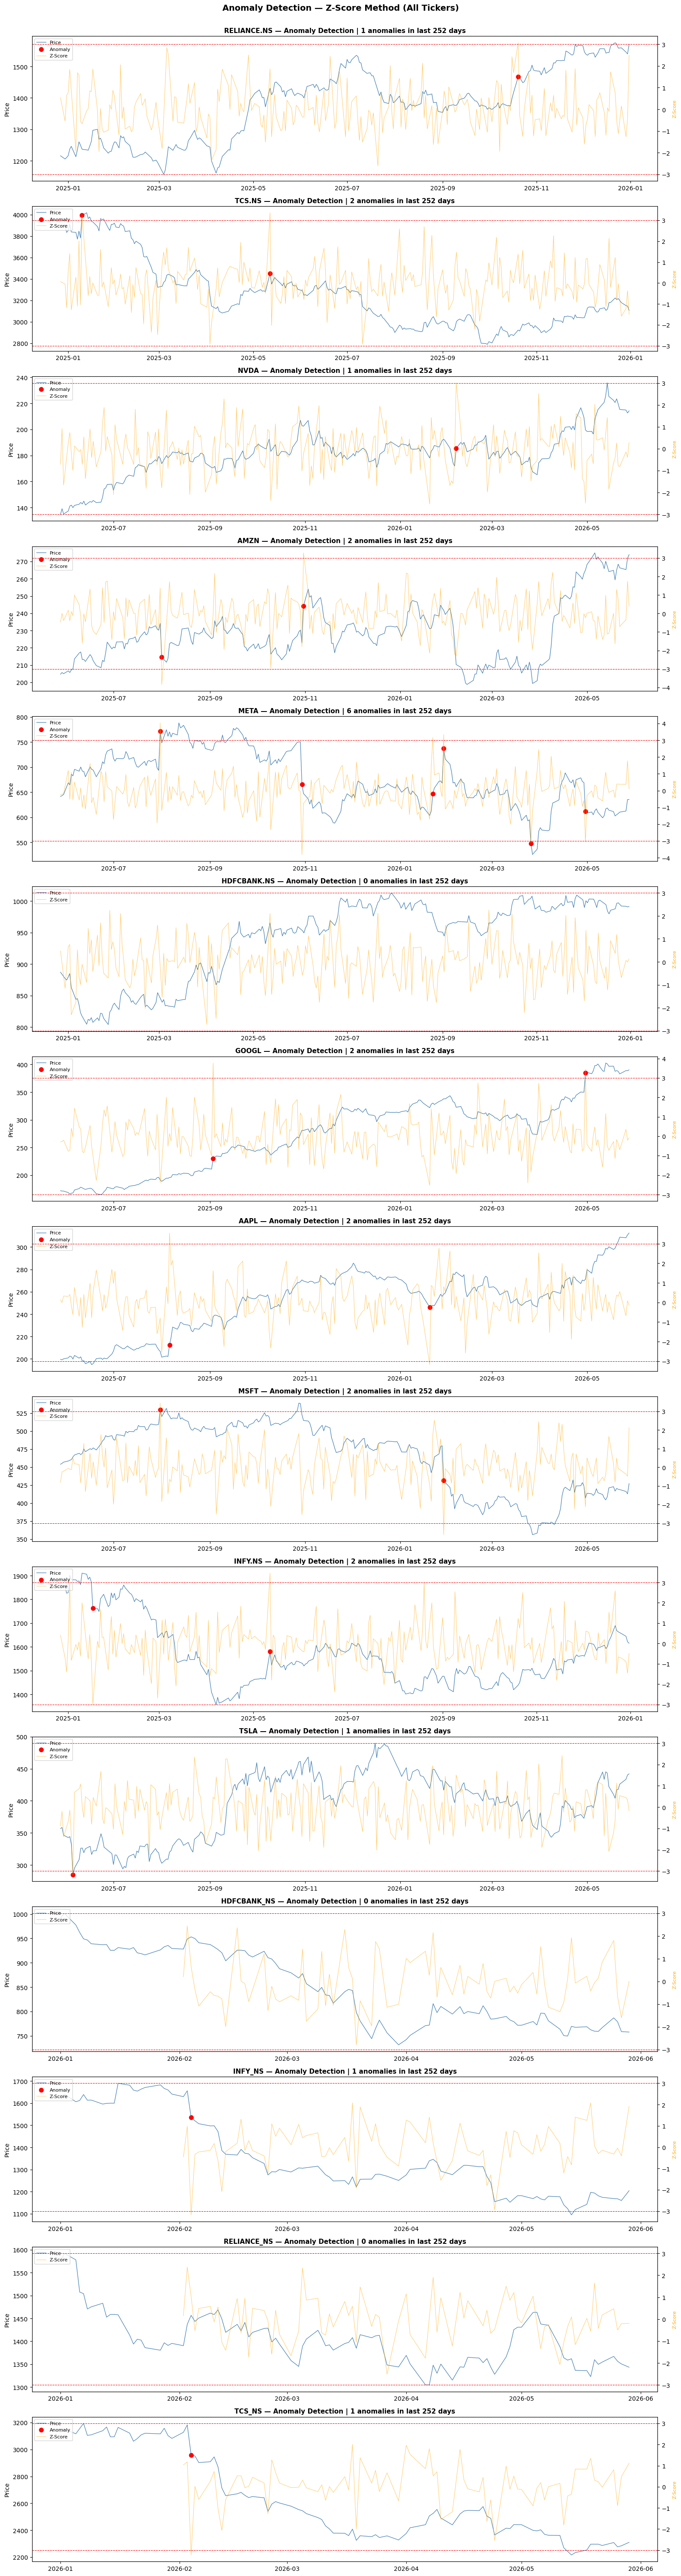


===== ANOMALY SUMMARY =====

             Total Anomalies  Worst Date Worst Z-Score
Ticker                                                
RELIANCE.NS               11  2020-03-09       -3.6379
TCS.NS                    14  2024-07-12        3.5387
NVDA                      13  2023-05-25        4.0249
AMZN                      13  2025-08-01        -3.839
META                      24  2018-07-26        -4.161
HDFCBANK.NS               11  2024-01-17       -3.9185
GOOGL                     13  2019-04-30       -4.0674
AAPL                      13  2024-06-11        3.6541
MSFT                      13  2024-10-31       -3.7848
INFY.NS                   12  2019-07-15        3.8656
TSLA                      14  2024-10-24        3.8709
HDFCBANK_NS                0           —             —
INFY_NS                    1  2026-02-04       -3.1795
RELIANCE_NS                0           —             —
TCS_NS                     1  2026-02-04       -3.2261

Anomaly data saved ✅


In [3]:
# anomaly_detection.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

def detect_anomalies_zscore(close_prices, window=21, threshold=3.0):
    print("\n===== ANOMALY DETECTION (Z-Score) =====\n")

    anomaly_dict = {}

    for ticker in close_prices.columns:
        series  = close_prices[ticker].dropna()
        returns = series.pct_change().dropna()

        # Rolling Z-score on returns
        roll_mean = returns.rolling(window).mean()
        roll_std  = returns.rolling(window).std()
        z_scores  = (returns - roll_mean) / roll_std

        # Flag anomalies
        anomalies = z_scores[np.abs(z_scores) > threshold]

        anomaly_dict[ticker] = {
            "series"    : series,
            "returns"   : returns,
            "z_scores"  : z_scores,
            "anomalies" : anomalies
        }

        print(f"{ticker:<15} → {len(anomalies)} anomalies detected")

    return anomaly_dict


def plot_anomalies(anomaly_dict, last_n_days=252):
    n        = len(anomaly_dict)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(16, n * 4))

    for i, (ticker, data) in enumerate(anomaly_dict.items()):
        series    = data["series"].iloc[-last_n_days:]
        z_scores  = data["z_scores"].iloc[-last_n_days:]
        anomalies = data["anomalies"]

        # Filter anomalies within window
        anomalies_in_window = anomalies[
            anomalies.index >= series.index[0]
        ]

        ax1 = axes[i]
        ax2 = ax1.twinx()   # second y-axis for z-score

        # Price line
        ax1.plot(series.index, series.values,
                 color="steelblue", linewidth=0.9, label="Price")

        # Anomaly points on price
        if not anomalies_in_window.empty:
            anomaly_prices = data["series"].loc[anomalies_in_window.index]
            ax1.scatter(anomaly_prices.index, anomaly_prices.values,
                        color="red", zorder=5, s=50, label="Anomaly")

        # Z-score line
        ax2.plot(z_scores.index, z_scores.values,
                 color="orange", linewidth=0.7,
                 alpha=0.6, label="Z-Score")
        ax2.axhline( 3, color="red", linestyle="--", linewidth=0.8)
        ax2.axhline(-3, color="red", linestyle="--", linewidth=0.8)
        ax2.set_ylabel("Z-Score", color="orange", fontsize=8)

        ax1.set_title(
            f"{ticker} — Anomaly Detection | "
            f"{len(anomalies_in_window)} anomalies in last {last_n_days} days",
            fontsize=11, fontweight="bold"
        )
        ax1.set_ylabel("Price")

        # Combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

    plt.suptitle("Anomaly Detection — Z-Score Method (All Tickers)",
                 fontsize=14, fontweight="bold", y=1.001)
    plt.tight_layout()
    plt.show()


def anomaly_summary(anomaly_dict):
    print("\n===== ANOMALY SUMMARY =====\n")

    rows = []
    for ticker, data in anomaly_dict.items():
        anomalies = data["anomalies"]
        if not anomalies.empty:
            worst_idx = anomalies.abs().idxmax()
            rows.append({
                "Ticker"       : ticker,
                "Total Anomalies" : len(anomalies),
                "Worst Date"   : str(worst_idx.date()),
                "Worst Z-Score": round(anomalies[worst_idx], 4)
            })
        else:
            rows.append({
                "Ticker"          : ticker,
                "Total Anomalies" : 0,
                "Worst Date"      : "—",
                "Worst Z-Score"   : "—"
            })

    summary_df = pd.DataFrame(rows).set_index("Ticker")
    print(summary_df.to_string())

    # Save for Streamlit
    pickle.dump(anomaly_dict, open("models/data/anomaly_dict.pkl", "wb"))
    print("\nAnomaly data saved ✅")
    return summary_df


# --- Run ---
anomaly_dict = detect_anomalies_zscore(close_prices, window=21, threshold=3.0)
plot_anomalies(anomaly_dict, last_n_days=252)
summary_df   = anomaly_summary(anomaly_dict)